In [53]:
import sys
!{sys.executable} -m pip install seaborn pandas matplotlib missingno plotly kagglehub scikit-learn xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ----- ---------------------------------- 13.1/101.7 MB 80.6 MB/s eta 0:00:02
   -------- ------------------------------- 21.5/101.7 MB 58.8 MB/s eta 0:00:02
   ------------------ --------------------- 47.4/101.7 MB 83.5 MB/s eta 0:00:01
   ---------------------------- ----------- 72.6/101.7 MB 94.4 MB/s eta 0:00:01
   --------------------------------------  99.1/101.7 MB 101.7 MB/s eta 0:00:01
   ---------------------------------------- 101.7/101.7 MB 88.5 MB/s  0:00:01



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Packages

In [7]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno

plt.rcParams['figure.figsize'] = [10, 5]
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)


### Read Uber Ride Analytic Dataset

In [8]:
df = pd.read_csv('Dataset/ncr_ride_bookings.csv')

## 1. Data Overview

In [9]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [10]:
df.shape

(150000, 21)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

In [12]:
df.describe(include='all')

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
count,150000,150000,150000,150000,150000,150000,150000,150000,139500.000000,102000.000000,10500.0,10500,27000.0,27000,9000.0,9000,102000.000000,102000.000000,93000.000000,93000.000000,102000
unique,365,62910,148767,5,148788,7,176,176,NaN,NaN,NaN,5,NaN,4,NaN,3,NaN,NaN,NaN,NaN,5
top,2024-11-16,17:44:57,"""CNR7908610""",Completed,"""CID6468528""",Auto,Khandsa,Ashram,NaN,NaN,NaN,Wrong Address,NaN,Customer related issue,NaN,Customer Demand,NaN,NaN,NaN,NaN,UPI
freq,462,16,3,93000,3,37419,949,936,NaN,NaN,NaN,2362,NaN,6837,NaN,3040,NaN,NaN,NaN,NaN,45909
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.456352,29.149636,1.0,NaN,1.0,NaN,1.0,NaN,508.295912,24.637012,4.230992,4.404584,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.773564,8.902577,0.0,NaN,0.0,NaN,0.0,NaN,395.805774,14.002138,0.436871,0.437819,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,10.000000,1.0,NaN,1.0,NaN,1.0,NaN,50.000000,1.000000,3.000000,3.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.300000,21.600000,1.0,NaN,1.0,NaN,1.0,NaN,234.000000,12.460000,4.100000,4.200000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.300000,28.800000,1.0,NaN,1.0,NaN,1.0,NaN,414.000000,23.720000,4.300000,4.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.300000,36.800000,1.0,NaN,1.0,NaN,1.0,NaN,689.000000,36.820000,4.600000,4.800000,NaN


## 2. Missing Value Analysis

In [13]:
df.isna().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

<Axes: >

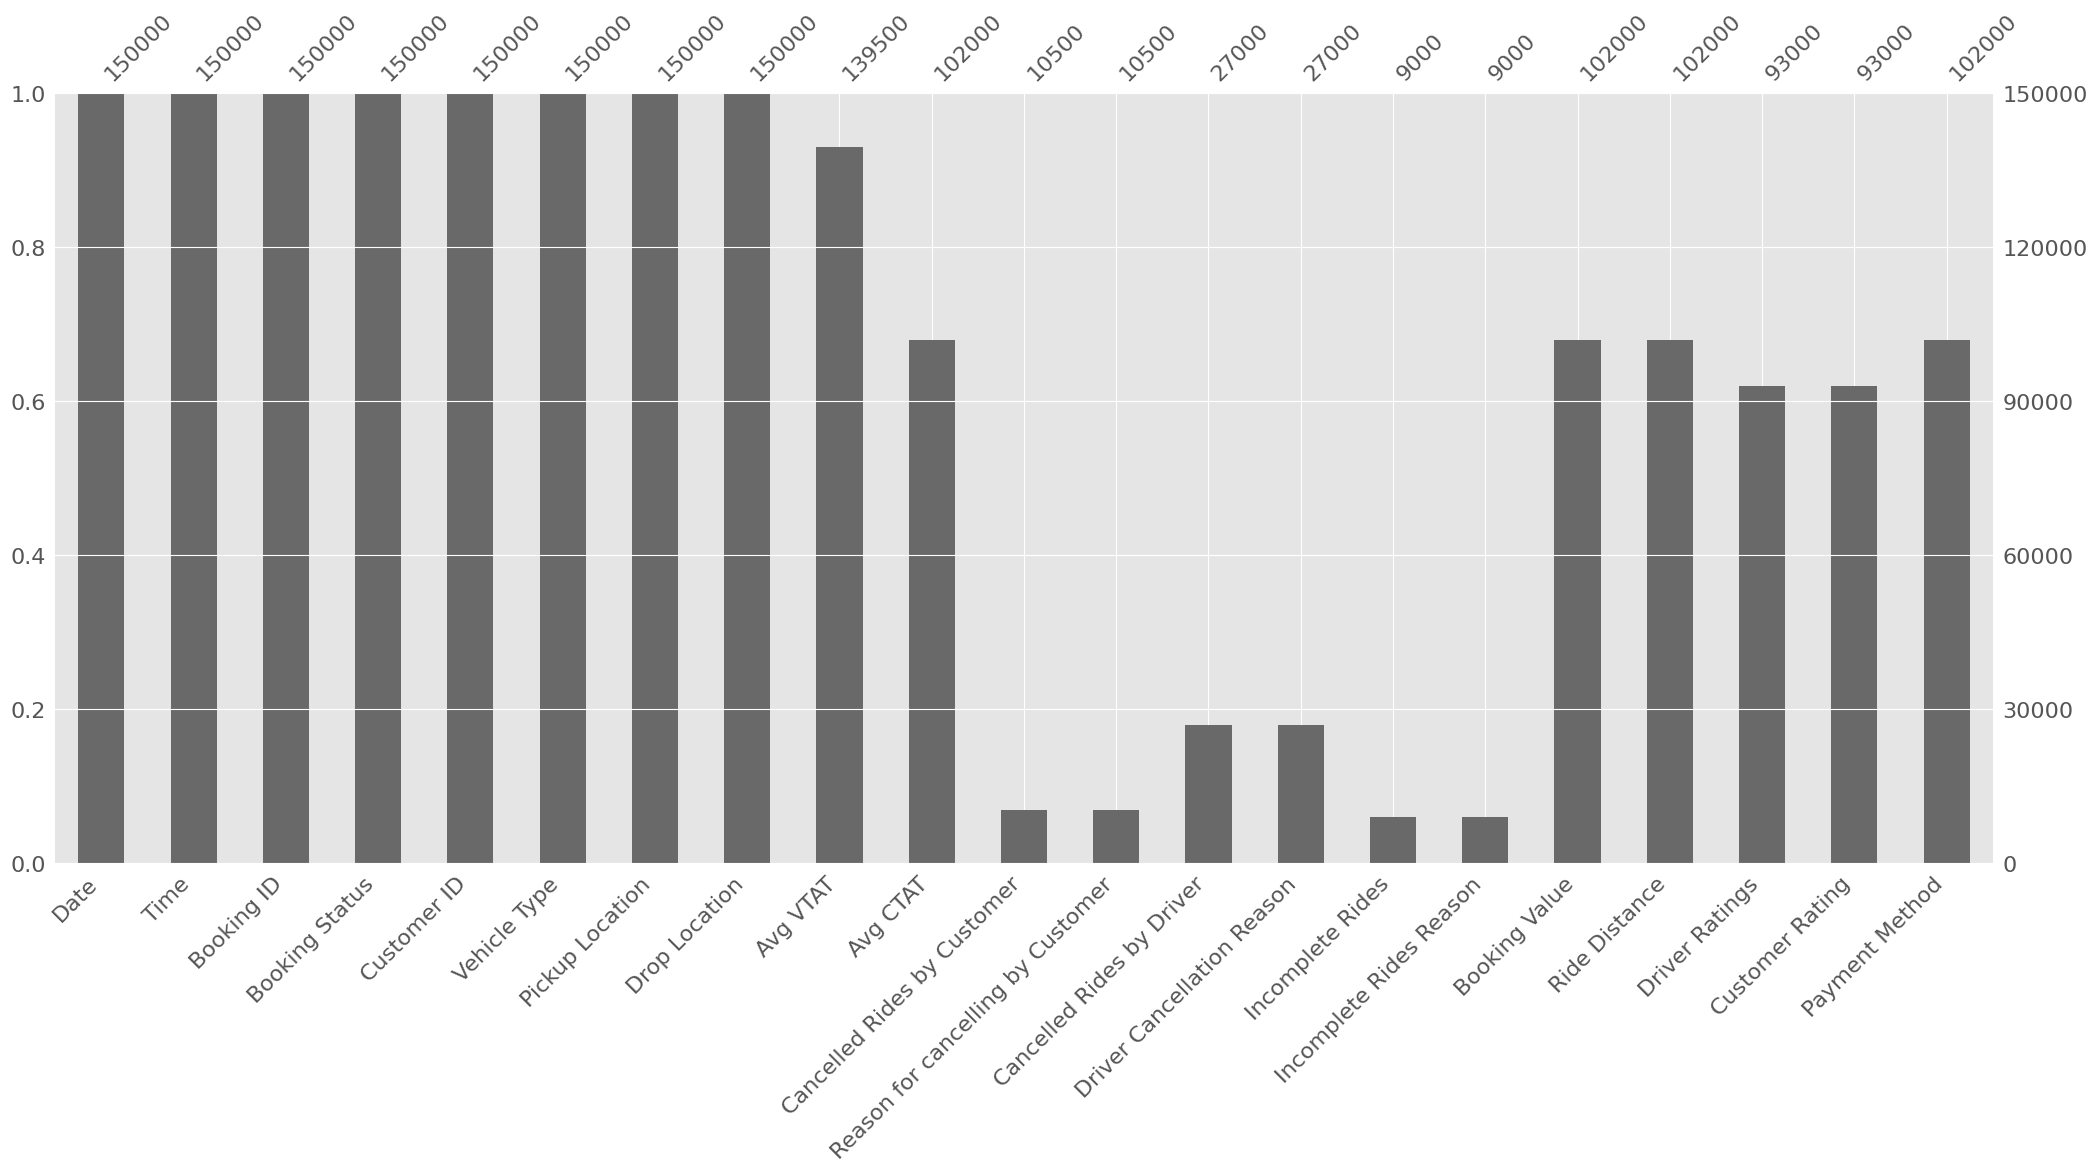

In [14]:
missingno.bar(df)

In [15]:
# Insight:
# Majority of missing values is concentrated in post ride features such as 
# Booking_Value, Ride_Distance, Driver Ratings and Customer_Rating.
# These are expected to be missing for non-completed rides, 
# therefore they do not indicate data quality issues.


## 3. Data Preparation

#### 3.1 Duplicate Analysis

In [16]:
# Check duplicate Booking IDs
df['Booking ID'].duplicated().sum()


np.int64(1233)

In [17]:
# Inspecting duplicated Booking IDs
dup_booking = df[df['Booking ID'].duplicated(keep=False)]
dup_booking.groupby('Booking ID').size().sort_values(ascending=False).head(10)

Booking ID
"CNR3648267"    3
"CNR5292943"    3
"CNR2726142"    3
"CNR6337479"    3
"CNR7199036"    3
"CNR7585544"    3
"CNR7642097"    3
"CNR7908610"    3
"CNR9603232"    3
"CNR1026036"    2
dtype: int64

In [18]:
# No exact duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [19]:
# Note : Booking ID
# Duplicate Booking IDs were identified (1233 occurrences)
# However, Each sharing the same Booking ID contained distinct information
# and no exact row duplicates.
# This indicates that Booking ID is not a reliable unique identifier for each ride booking.
# Therefore, it was excluded from further analysis.

#### 3.2 Feature Engineering + Column Cleaning

In [20]:
# Conversion of Date and Time (Weekday)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.insert(df.columns.get_loc('Date')+1, 'Hour', pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour)
df.insert(df.columns.get_loc('Date')+2, 'Weekday', df['Date'].dt.day_name())

In [21]:
# Dropping unnecessary columns
df = df.drop(['Booking ID', 'Time'], axis=1)

In [22]:
# Renaming columns
df = df.rename(columns={'Booking Status' : 'Booking_Status',
                   'Customer ID' : 'Customer_ID',
                   'Vehicle Type' : 'Vehicle_Type',
                   'Pickup Location' : 'Pickup_Location',
                   'Drop Location' : 'Drop_Location',
                   'Avg VTAT' : 'Avg_VTAT',
                   'Avg CTAT' : 'Avg_CTAT',
                   'Cancelled Rides by Customer' : 'Cancelled_Rides_by_Customer',
                   'Reason for cancelling by Customer' : 'Customer_Cancellation_Reason',
                   'Cancelled Rides by Driver' : 'Cancelled_Rides_by_Driver',
                   'Driver Cancellation Reason' : 'Driver_Cancellation_Reason',
                   'Incomplete Rides': 'Incomplete_Rides',
                   'Incomplete Rides Reason' : 'Incomplete_Reason',
                   'Booking Value' : 'Booking_Value',
                   'Ride Distance' : 'Ride_Distance',
                   'Driver Ratings' : 'Driver_Rating',
                   'Customer Rating' : 'Customer_Rating',
                   'Payment Method' : 'Payment_Method'})



In [23]:
df.head()

,Date,Hour,Weekday,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,Avg_VTAT,Avg_CTAT,Cancelled_Rides_by_Customer,Customer_Cancellation_Reason,Cancelled_Rides_by_Driver,Driver_Cancellation_Reason,Incomplete_Rides,Incomplete_Reason,Booking_Value,Ride_Distance,Driver_Rating,Customer_Rating,Payment_Method
0,2024-03-23,12,Saturday,No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18,Friday,Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,8,Friday,Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17,Monday,Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22,Monday,Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


## 4. Univariate Analysis

Booking_Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


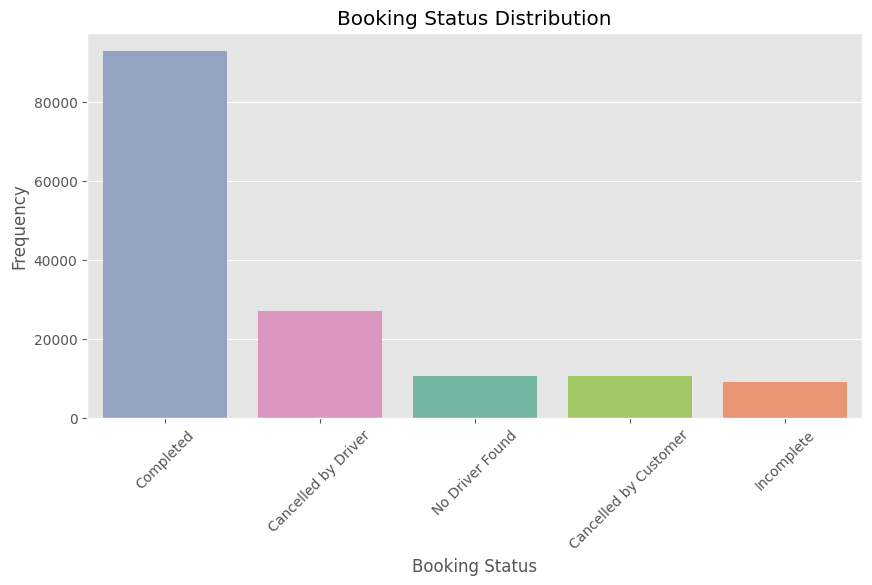

In [24]:
print(df['Booking_Status'].value_counts())
sns.countplot(
    data=df, 
    x='Booking_Status', 
    hue = 'Booking_Status',
    palette= 'Set2', 
    order=df['Booking_Status'].value_counts().index,
    legend=False
)
plt.title("Booking Status Distribution")
plt.xticks(rotation=45)
plt.xlabel("Booking Status")
plt.ylabel("Frequency")
plt.show()

In [25]:
# Insight: 
# Approximately, 
# Completed Booking : 62 %
# Cancelled By Driver : 18 %
# Cancelled By Customer : 7 %
# No Driver Found : 7 %
# Incomplete : 6 %

# Driver Cancellation > Customer Cancellation:
# Driver cancelled approximately 2.6x more than Customer

# Class Imbalance:
# This dataset shows a moderate class imbalance, with  62 % Completed rides
# and 38% non-completed rides.

Vehicle_Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64


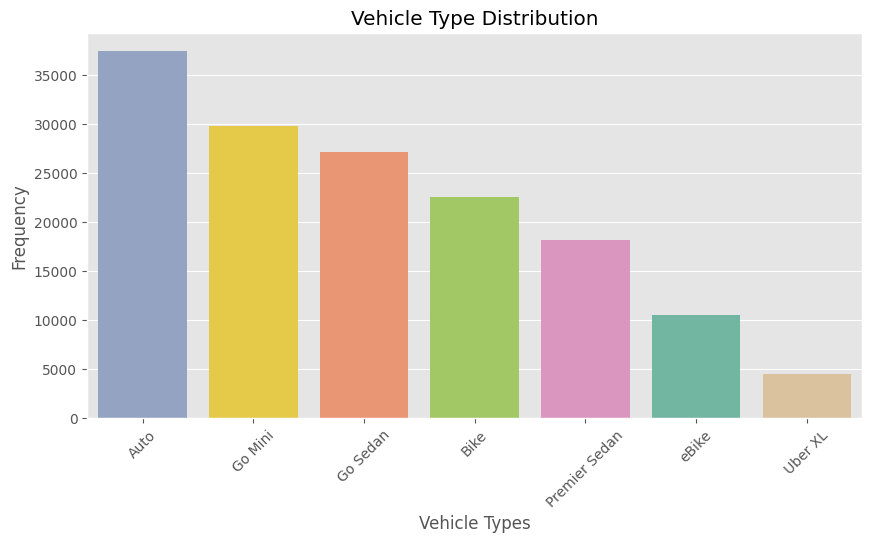

In [26]:
print(df['Vehicle_Type'].value_counts())
sns.countplot(
    data=df, 
    x='Vehicle_Type', 
    hue = 'Vehicle_Type',
    palette= 'Set2', 
    order=df['Vehicle_Type'].value_counts().index,
    legend=False
)
plt.title("Vehicle Type Distribution")
plt.xticks(rotation=45)
plt.xlabel("Vehicle Types")
plt.ylabel("Frequency")
plt.show()

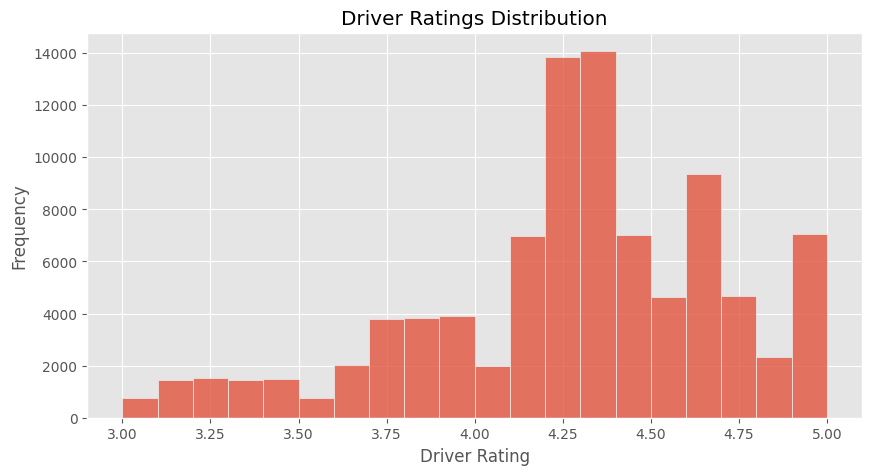

In [27]:
sns.histplot(df['Driver_Rating'].dropna(), bins=20)
plt.title("Driver Ratings Distribution")
plt.xlabel("Driver Rating")
plt.ylabel("Frequency")
plt.show()

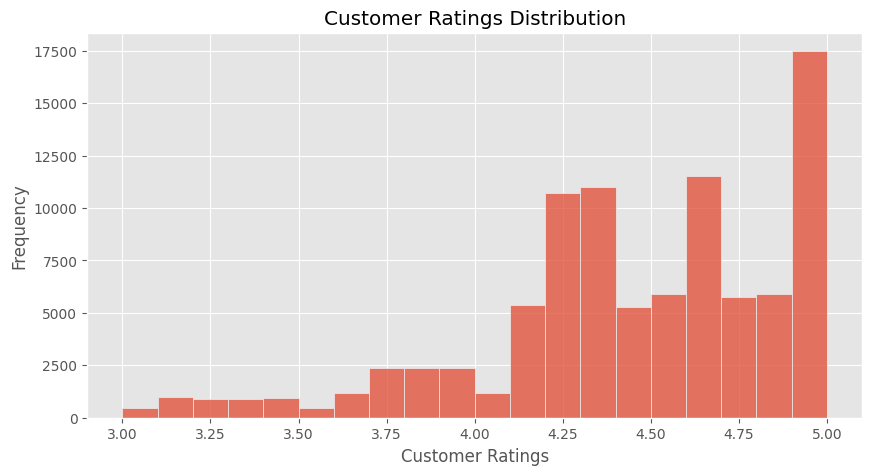

In [28]:
sns.histplot(df['Customer_Rating'].dropna(), bins=20)
plt.title("Customer Ratings Distribution")
plt.xlabel("Customer Ratings")
plt.ylabel("Frequency")
plt.show()

## 5. Cancellation Analysis

#### 5.1 Cancellation Reasons

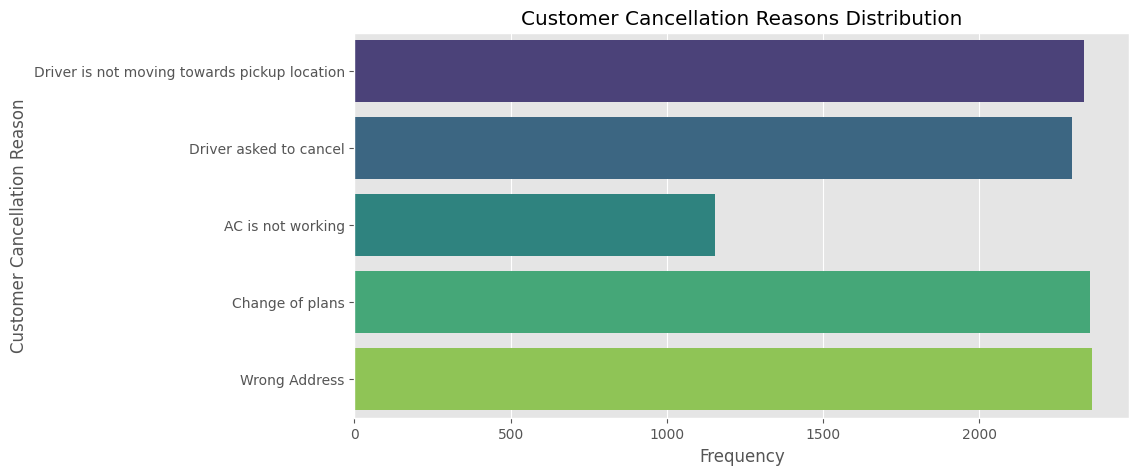

,Reason,Customer %
0,Wrong Address,22.50
1,Change of plans,22.41
2,Driver is not moving towards pickup location,22.24
3,Driver asked to cancel,21.86
4,AC is not working,11.00


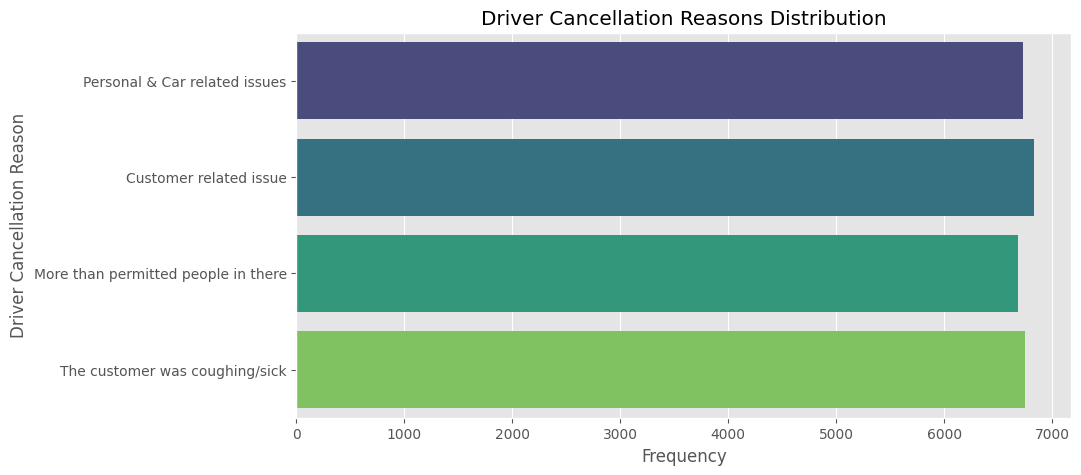

,Reason,Driver %
0,Customer related issue,25.32
1,The customer was coughing/sick,25.00
2,Personal & Car related issues,24.91
3,More than permitted people in there,24.76


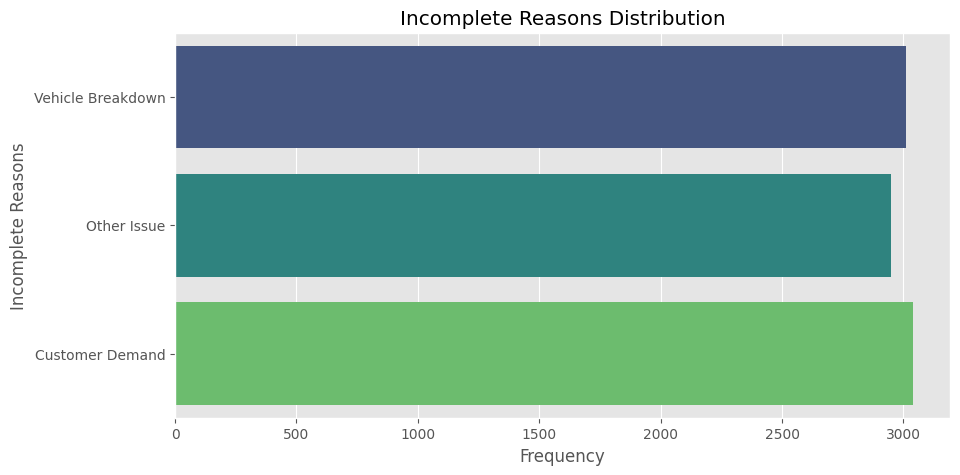

,Reason,Incomplete %
0,Customer Demand,33.8
1,Vehicle Breakdown,33.5
2,Other Issue,32.8


In [29]:
# customer cancellation reason
customer_cancellation = df[df['Booking_Status']=="Cancelled by Customer"]
sns.countplot(
    data=customer_cancellation, 
    y='Customer_Cancellation_Reason', 
    hue = 'Customer_Cancellation_Reason',
    palette= 'viridis',
    legend=False
)
plt.title("Customer Cancellation Reasons Distribution")
plt.ylabel("Customer Cancellation Reason")
plt.xlabel("Frequency")
plt.show()

customer = customer_cancellation['Customer_Cancellation_Reason']  \
             .value_counts(normalize=True).mul(100).round(2)  \
             .rename_axis('Reason').reset_index(name='Customer %')
display(customer)

# driver cancellation reason
driver_cancellation = df[df['Booking_Status']=="Cancelled by Driver"]
sns.countplot(
    data=driver_cancellation, 
    y='Driver_Cancellation_Reason', 
    hue = 'Driver_Cancellation_Reason',
    palette= 'viridis',
    legend=False
)
plt.title("Driver Cancellation Reasons Distribution")
plt.ylabel("Driver Cancellation Reason")
plt.xlabel("Frequency")
plt.show()

driver = driver_cancellation['Driver_Cancellation_Reason']  \
           .value_counts(normalize=True).mul(100).round(2)  \
           .rename_axis('Reason').reset_index(name='Driver %')
display(driver)

# Incomplete Reason
incomplete_cancellation = df[df['Booking_Status']=="Incomplete"]
sns.countplot(
    data=incomplete_cancellation, 
    y='Incomplete_Reason', 
    hue = 'Incomplete_Reason',
    palette='viridis',
    legend=False
)
plt.title("Incomplete Reasons Distribution")
plt.ylabel("Incomplete Reasons")
plt.xlabel("Frequency")
plt.show()

incomplete = df[df['Booking_Status']=="Incomplete"]['Incomplete_Reason']  \
               .value_counts(normalize=True).mul(100).round(1)  \
               .rename_axis('Reason').reset_index(name='Incomplete %')
display(incomplete)



In [30]:
# Insight:
# Cancellation reasons are relatively evenly distributed across all three categories,
# suggesting cancellations are driven by multiple factors rather than
# a single dominant cause.

# Customer Cancellations (~22% each):
# - "Wrong address", "Change of plans", and "Driver not moving" occur at similar rates.
# - On the other hand, "AC not working" is noticeably less frequent (11%) 

# Driver Cancellations (~25% each):
# - Reasons are evenly distributed and primarily customer related
# - (health concern, capacity issues, behavior)

# Incomplete Rides (~33% each):
# - Reasons are evenly split between customer demand, vehicle breakdown, and other

#### 5.2 Data Availability

In [31]:
df.groupby('Booking_Status')[['Booking_Value','Driver_Rating',
                              'Customer_Rating','Vehicle_Type',
                              'Avg_VTAT', 'Avg_CTAT',
                              'Pickup_Location', 'Drop_Location',
                              'Ride_Distance', 'Payment_Method']].apply(lambda x: x.isna().mean())



,Booking_Value,Driver_Rating,Customer_Rating,Vehicle_Type,Avg_VTAT,Avg_CTAT,Pickup_Location,Drop_Location,Ride_Distance,Payment_Method
Booking_Status,,,,,,,,,,
Cancelled by Customer,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
Cancelled by Driver,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
Completed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Incomplete,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
No Driver Found,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0


In [32]:
# Note:
# Booking_Value, Driver_Rating, and Customer_Rating are only available for completed rides
# and entirely missing for cancelled bookings. Similarly, Ride_distance, Avg_CTAT, 
# Payment_Method are not fully available for all cancelled rides. 

# Therefore, these features cannot be used to analyze cancellation behavior.

# To explore cancellation patters, we focus on features that are available prior to 
# completion of ride, this includes Vehicle_Type, Avg_VTAT, Pickup_Location, 
# Drop_Location, Hour, and Weekday.

#### 5.3 Feature Impact on Cancellation

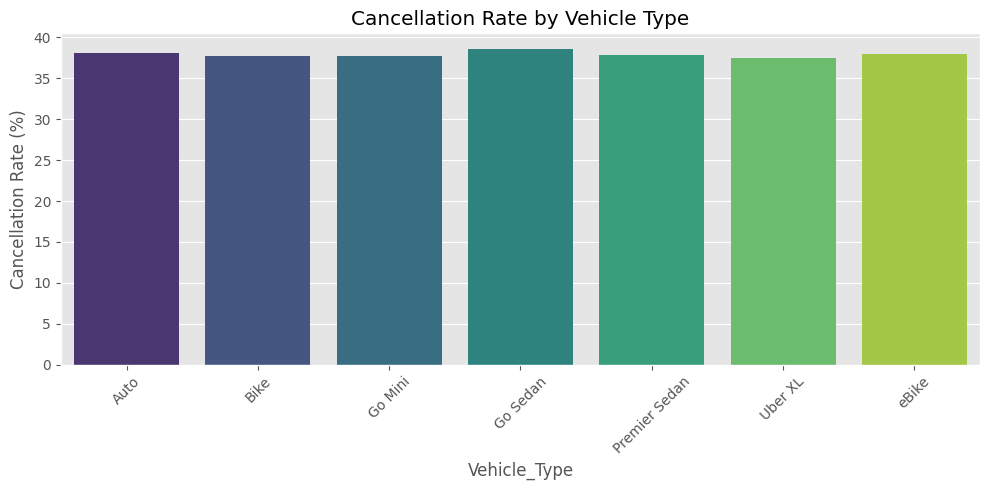

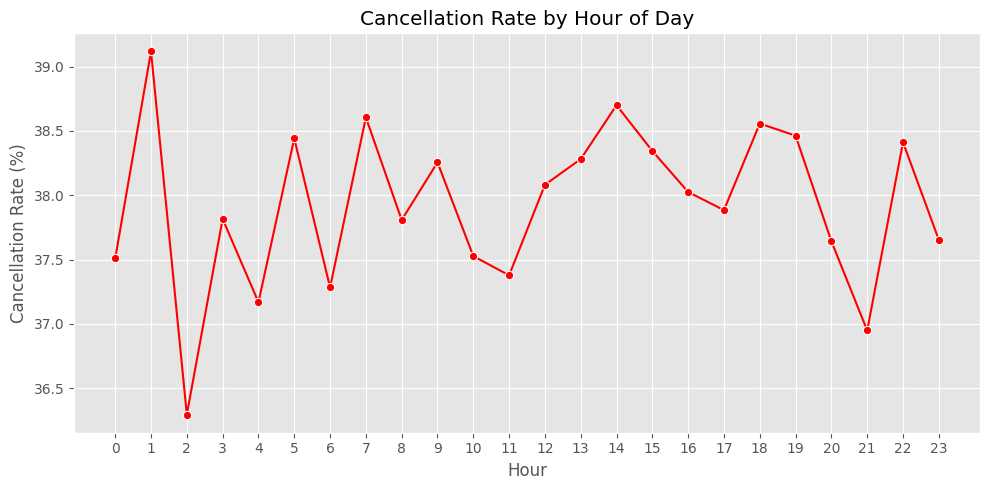

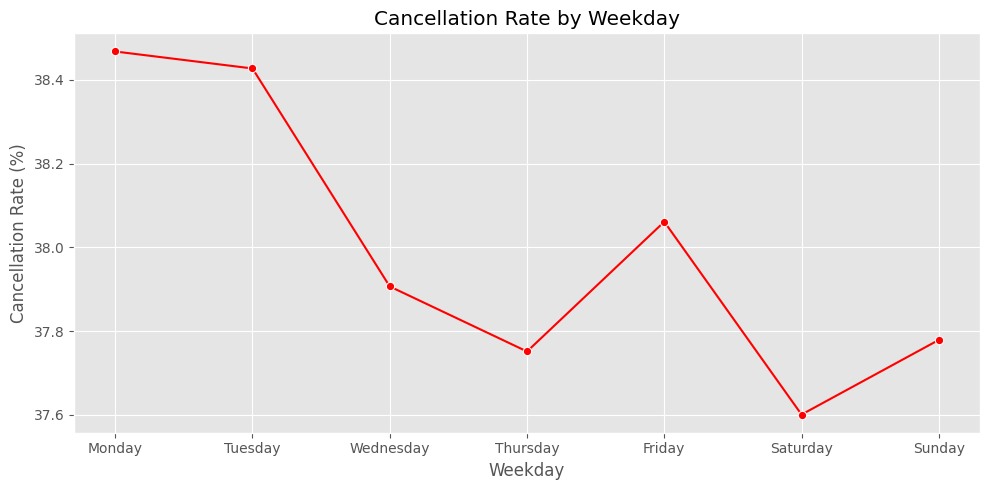

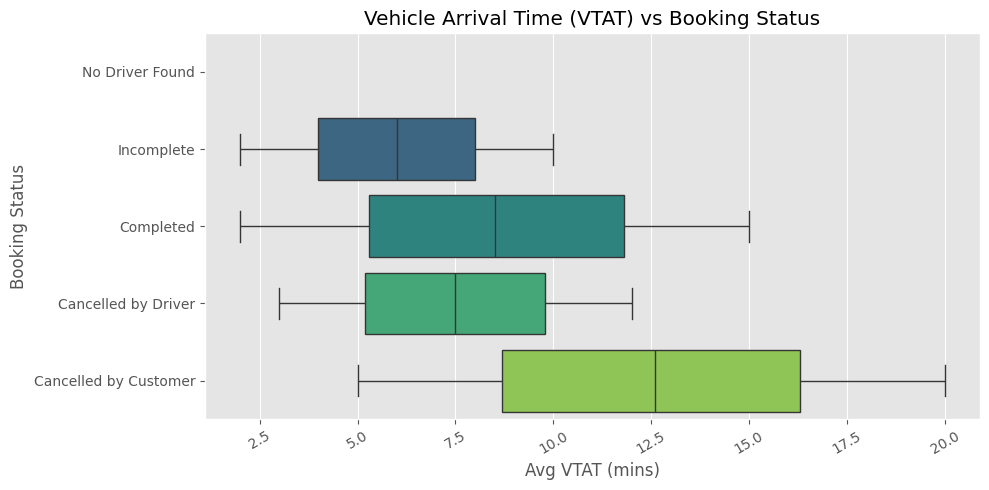

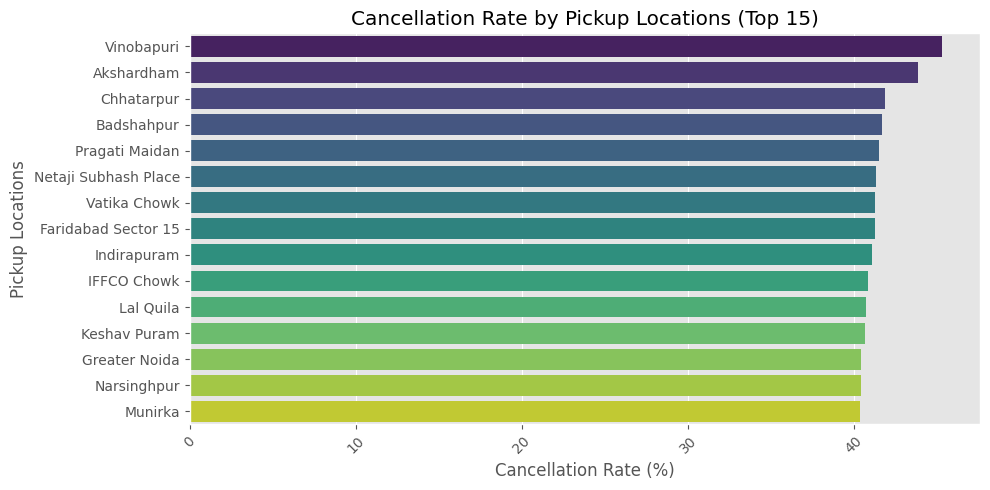

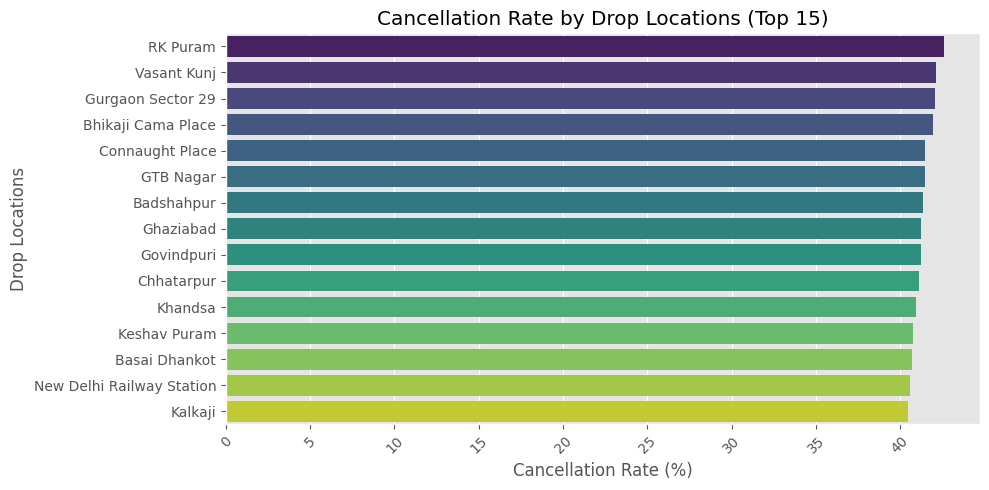

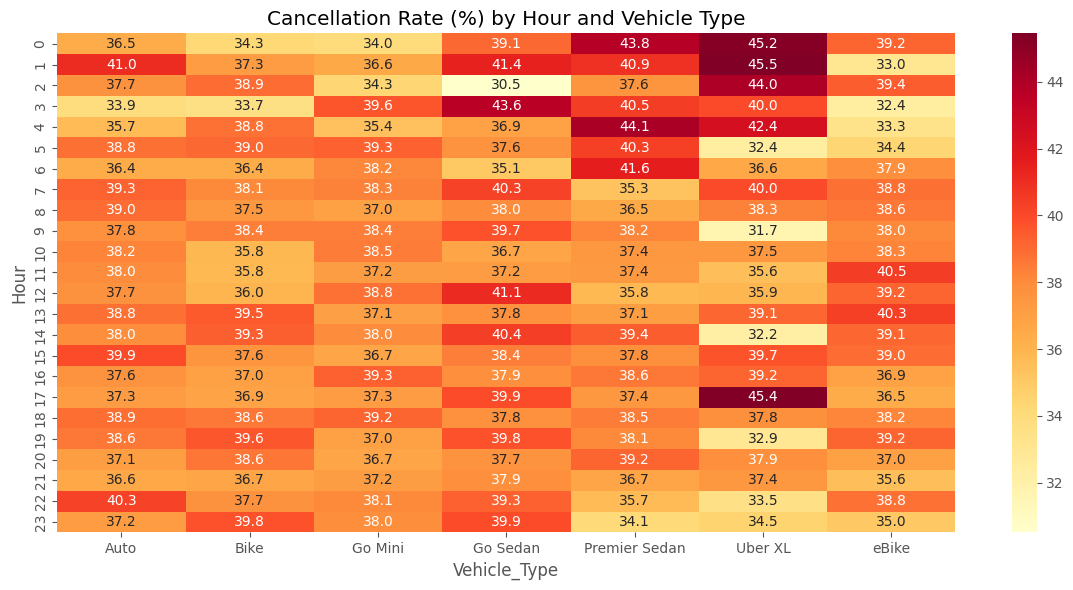

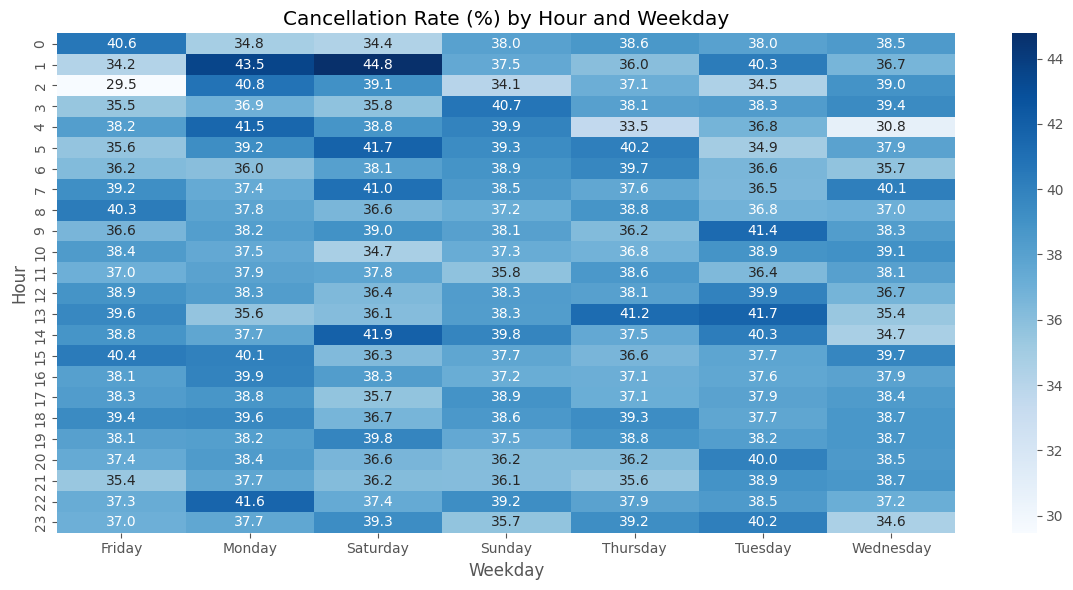

In [33]:
# create a binary: 0 if Completed 1 if Not Completed
df['Is_Cancelled'] = (df['Booking_Status'] != "Completed").astype(int)

# Cancellation by vehicle
cancel_by_vehicle = df.groupby('Vehicle_Type')['Is_Cancelled'] \
                        .mean() \
                        .mul(100) \
                        .reset_index(name='Cancellation_Rate')

sns.barplot(
    data=cancel_by_vehicle, 
    x='Vehicle_Type', 
    y='Cancellation_Rate', 
    hue='Vehicle_Type', 
    palette='viridis')
plt.title('Cancellation Rate by Vehicle Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cancellation by hour
cancel_by_hour = df.groupby('Hour')['Is_Cancelled'] \
                        .mean() \
                        .mul(100) \
                        .reset_index(name='Cancellation_Rate')

sns.lineplot(data=cancel_by_hour, x='Hour', y='Cancellation_Rate', marker='o', color='red')
plt.title('Cancellation Rate by Hour of Day')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

# Cancellation by weekday
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
cancel_by_weekday = df.groupby('Weekday')['Is_Cancelled'] \
                        .mean() \
                        .mul(100) \
                        .reindex(order) \
                        .reset_index(name='Cancellation_Rate')  

sns.lineplot(data=cancel_by_weekday, x='Weekday', y='Cancellation_Rate', marker='o', color='red')
plt.title('Cancellation Rate by Weekday')
plt.ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.show()


# Cancellation by Avg_VTAT
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df, 
    y='Booking_Status', 
    x='Avg_VTAT', 
    hue='Booking_Status', 
    palette='viridis')
plt.title('Vehicle Arrival Time (VTAT) vs Booking Status')
plt.ylabel('Booking Status')
plt.xlabel('Avg VTAT (mins)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Cancel by Pickup_Location top 15
cancel_by_pickup = df.groupby('Pickup_Location')['Is_Cancelled'] \
                        .mean() \
                        .mul(100) \
                        .reset_index(name='Cancellation_Rate')  \
                        .sort_values('Cancellation_Rate', ascending=False)
    
sns.barplot(
    data=cancel_by_pickup.head(15), 
    y='Pickup_Location', 
    x='Cancellation_Rate', 
    hue='Pickup_Location', 
    palette='viridis')
plt.title('Cancellation Rate by Pickup Locations (Top 15)')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Pickup Locations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# Cancel by Drop_location top 15
cancel_by_drop = df.groupby('Drop_Location')['Is_Cancelled'] \
                        .mean() \
                        .mul(100) \
                        .reset_index(name='Cancellation_Rate')  \
                        .sort_values('Cancellation_Rate', ascending=False)
sns.barplot(
    data=cancel_by_drop.head(15), 
    y='Drop_Location', 
    x='Cancellation_Rate', 
    hue='Drop_Location', 
    palette='viridis')
plt.title('Cancellation Rate by Drop Locations (Top 15)')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Drop Locations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


pivot1 = df.groupby(['Hour', 'Vehicle_Type'])['Is_Cancelled'].mean().mul(100).unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Cancellation Rate (%) by Hour and Vehicle Type')
plt.tight_layout()
plt.show()

pivot2 = df.groupby(['Hour', 'Weekday'])['Is_Cancelled'].mean().mul(100).unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='Blues')
plt.title('Cancellation Rate (%) by Hour and Weekday')
plt.tight_layout()
plt.show()



## 6. 📊 EDA Summary

#### 🧾 Dataset Overview
- **150,000 rides** across **148,788 unique customers**
- **No notable issues** in data quality: no duplicate rows were found
- Missing values are expected (post-ride features missing for non-completed rides)

#### ⚖️ Class Distribution
| Booking Status           | Percentage |
|-------------------------|-----------|
| Completed               | 62%       |
| Cancelled by Driver     | 18%       |
| Cancelled by Customer   | 7%        |
| No Driver Found         | 7%        |
| Incomplete              | 6%        |

#### Class Imbalance
- **62% Completed vs 38% Non-completed** 
  - Indicates a moderate class imbalance  

#### 🔍 Key Insights

##### Driver vs Customer Cancellations
- Driver cancellations occur approximately **2.6×** more frequently than customer cancellations

##### Cancellation Reasons
- No single domiant reason across driver, customer, or incomplete rides
- Reasons are **relatively evenly distributed**
- Cancellations are driven by multiple factors and situational 

##### Vehicle Arrival Time (VTAT)
- Cancelled rides show **higher average VTAT** compared to completed rides
  - suggests **longer wait times increase the likelihood of cancellation**

##### Temporal Patterns
- Hour and Weekday show relatively small variation in cancellation rates
  - Weak individual predictors, but may contribute through feature interaction

##### Location Risk
- Certain pickup and drop locations show consistently higher cancellation rates
  - Indicates localized demand-supply imbalance


## 7. Feature Engineering + Data Preprocessing

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import numpy as np


In [35]:
# Feature Selection
# We only keep pre-ride features to avoid data leakage
feature = ['Vehicle_Type', 'Avg_VTAT', 'Hour', 'Weekday', 
                'Pickup_Location', 'Drop_Location']

target = 'Is_Cancelled'

# Encode Categorical Features
# Vehicle_Type
le_vh = LabelEncoder()
df['Vehicle_Type'] = le_vh.fit_transform(df['Vehicle_Type'])

# Weekday
le_we = LabelEncoder()
df['Weekday'] = le_vh.fit_transform(df['Weekday'])

X = df[feature].copy()
Y = df[target].copy()

In [36]:
# Traning and Test data split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, 
    stratify=Y, random_state=42)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

Train size : (120000, 6)
Test size  : (30000, 6)


In [37]:
# Encode Pickup and Drop location using mean
# Fill nan with global mean
train_df = X_train.copy()
train_df['Is_Cancelled'] = Y_train.values

# compute mean for train
pickup_r = train_df.groupby('Pickup_Location')['Is_Cancelled'].mean()
drop_r  = train_df.groupby('Drop_Location')['Is_Cancelled'].mean()

# global mean 
global_mean = Y_train.mean()

X_train['Pickup_Location'] = X_train['Pickup_Location'].map(pickup_r).fillna(global_mean)
X_train['Drop_Location']   = X_train['Drop_Location'].map(drop_r).fillna(global_mean)

X_test['Pickup_Location']  = X_test['Pickup_Location'].map(pickup_r).fillna(global_mean)
X_test['Drop_Location']    = X_test['Drop_Location'].map(drop_r).fillna(global_mean)

In [38]:
# Handling null values for Avg_VTAT
imputer = SimpleImputer(strategy='median')
X_train[['Avg_VTAT']] = imputer.fit_transform(X_train[['Avg_VTAT']])
X_test[['Avg_VTAT']]  = imputer.transform(X_test[['Avg_VTAT']])


In [39]:
# Compute Class Weight 
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=Y_train
)


In [134]:
results = {}

## 8. Random Forest

In [135]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

weights = dict(enumerate(class_weights))

random_forest = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
# Train
random_forest.fit(X_train, Y_train)

# Predict and Evaluation
Y_pred = random_forest.predict(X_test)
Y_prob = random_forest.predict_proba(X_test)[:, 1]

results['Random_Forest'] = {
    'auc'   : roc_auc_score(Y_test,Y_prob),
    'report': classification_report(Y_test, Y_pred, output_dict=True),
    'Y_prob': Y_prob,
    'Y_pred': Y_pred,
}

print("****************Random Forest****************\n")
print("ROC AUC Score:", results['Random_Forest']['auc'])
print("\nClassification Report:\n", classification_report(Y_test, Y_pred, digits=3))

****************Random Forest****************

ROC AUC Score: 0.71843270609319

Classification Report:
               precision    recall  f1-score   support

           0      0.735     0.637     0.683     18600
           1      0.514     0.626     0.565     11400

    accuracy                          0.633     30000
   macro avg      0.625     0.632     0.624     30000
weighted avg      0.651     0.633     0.638     30000



## 9. XGBoost

In [136]:
import xgboost as xgb
# Weights
neg = (Y_train == 0).sum()
pos = (Y_train == 1).sum()
scale_pos_weights = neg / pos

xgbs = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weights,
    n_estimators=400,
    max_depth=5,
    learning_rate=0.04,
    random_state=42,
    n_jobs=-1
)
# Train
xgbs.fit(X_train, Y_train)

# Predict and Evaluation
Y_pred = xgbs.predict(X_test)
Y_prob = xgbs.predict_proba(X_test)[:, 1]

results['XGBoost'] = {
    'auc'   : roc_auc_score(Y_test,Y_prob),
    'report': classification_report(Y_test, Y_pred, digits=3, output_dict=True),
    'Y_prob': Y_prob,
    'Y_pred': Y_pred,
}

print("****************XGBoost****************\n")
print("ROC AUC Score:", results['XGBoost']['auc'])
print("\nClassification Report:\n", classification_report(Y_test, Y_pred, digits=3))

****************XGBoost****************

ROC AUC Score: 0.7194873820977175

Classification Report:
               precision    recall  f1-score   support

           0      0.740     0.630     0.680     18600
           1      0.514     0.640     0.570     11400

    accuracy                          0.633     30000
   macro avg      0.627     0.635     0.625     30000
weighted avg      0.654     0.633     0.639     30000



## 10. Logistic Regression

In [137]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

logistic_reg = LogisticRegression(
    class_weight=weights,
    max_iter=1000,
    random_state=42
)
logistic_reg.fit(X_train_scaled, Y_train)

Y_pred = logistic_reg.predict(X_test_scaled)
Y_prob = logistic_reg.predict_proba(X_test_scaled)[:, 1]

results['Logistic_Regression'] = {
    'auc'   : roc_auc_score(Y_test,Y_prob),
    'report': classification_report(Y_test, Y_pred, digits=3, output_dict=True),
    'Y_prob': Y_prob,
    'Y_pred': Y_pred,
}

print("ROC AUC Score:", results['Logistic_Regression']['auc'])
print("\nClassification Report:\n", classification_report(Y_test, Y_pred, digits=3))



ROC AUC Score: 0.5061990756461046

Classification Report:
               precision    recall  f1-score   support

           0      0.623     0.505     0.558     18600
           1      0.383     0.501     0.434     11400

    accuracy                          0.504     30000
   macro avg      0.503     0.503     0.496     30000
weighted avg      0.532     0.504     0.511     30000



## 11. Predictive Models Summary

In [138]:
summary = pd.DataFrame([{
    'Model'      : name,
    'AUC'        : round(res['auc'], 4),
    'Precision'  : round(res['report']['1']['precision'], 3),
    'Recall'     : round(res['report']['1']['recall'], 3),
    'F1 Score'   : round(res['report']['1']['f1-score'], 3),
    'Accuracy'   : round(res['report']['accuracy'], 3),
} for name, res in results.items()]).set_index('Model')

print("\nFinal Model Summary ")
print(summary)


Final Model Summary 
                        AUC  Precision  Recall  F1 Score  Accuracy
Model                                                             
Random_Forest        0.7184      0.514   0.626     0.565     0.633
XGBoost              0.7195      0.514   0.640     0.570     0.633
Logistic_Regression  0.5062      0.383   0.501     0.434     0.504


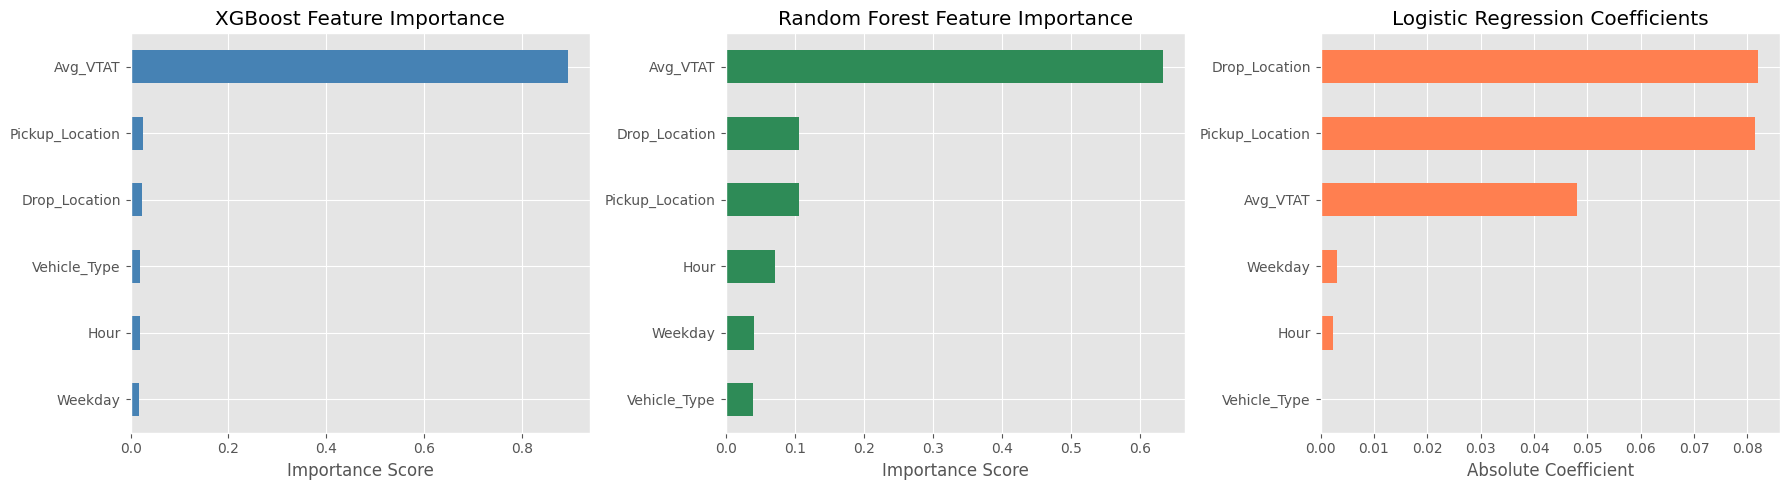

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# XGBoost
fi_xgb = pd.Series(
    xgbs.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fi_xgb.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('XGBoost Feature Importance')
axes[0].set_xlabel('Importance Score')

# Random Forest
fi_rf = pd.Series(
    random_forest.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fi_rf.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Random Forest Feature Importance')
axes[1].set_xlabel('Importance Score')

# Logistic Regression
fi_lr = pd.Series(
    np.abs(logistic_reg.coef_[0]),
    index=X_train.columns
).sort_values(ascending=True)

fi_lr.plot(kind='barh', ax=axes[2], color='coral')
axes[2].set_title('Logistic Regression Coefficients')
axes[2].set_xlabel('Absolute Coefficient')

plt.tight_layout()
plt.show()

**Best Model:** XGBoost
- Highest AUC (0.720) and Recall (0.640) across all metrics

**Feature Importance Finding**
- Avg_VTAT is the single strongest predictor across all three models
- All other features (Hour, Weekday, Vehicle Type) contribute weak predictive signal

**Model Performance Interpretation:**
- The moderate performance is not a modelling failure rather it is a direct consequence of the features available at prediction time.
    - Pre-ride features **(Hour, Weekday, Vehicle Type)** carry weak predictive signal
    - Most potentially informative features such as (Driver_Rating, Booking_Value) are provided after completing ride. Thus, including them would introduce data leakage.

**Room for Improvement**
Model performance could be significantly improved with more predictive features:
- Customer cancellation history
- Driver reliability or acceptance Rate
- Real-time context (traffic and weather conditions)

I